# Tensile

For 3D printed parts, interlayer bonding, aka Z tensile strength, is arguably the most important mechanical property. It is almost always the weakest among all mechanical properties, and is influenced by the process. In this notebook, we analyze tensile strength data of various forms, hoping to get a better understanding of how presets can be optimized for Z tensile strength.

## 0 Packages

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import matplotlib
matplotlib.rcParams["font.family"] = "STIXGeneral"
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams["xtick.direction"] = "in"
matplotlib.rcParams["ytick.direction"] = "in"
plt.rcParams['xtick.major.size'] = 2  # Length of major ticks
plt.rcParams['ytick.major.size'] = 2  # Length of major ticks
plt.rcParams['xtick.minor.size'] = 1  # Length of minor ticks
plt.rcParams['ytick.minor.size'] = 1  # Length of minor ticks

## 1 Print speed

In [3]:
folder = Path("~/Downloads").expanduser()
pc = pd.read_csv(folder / "pc_speed_tensile.csv")
pa = pd.read_csv(folder / "pa_speed_tensile.csv")

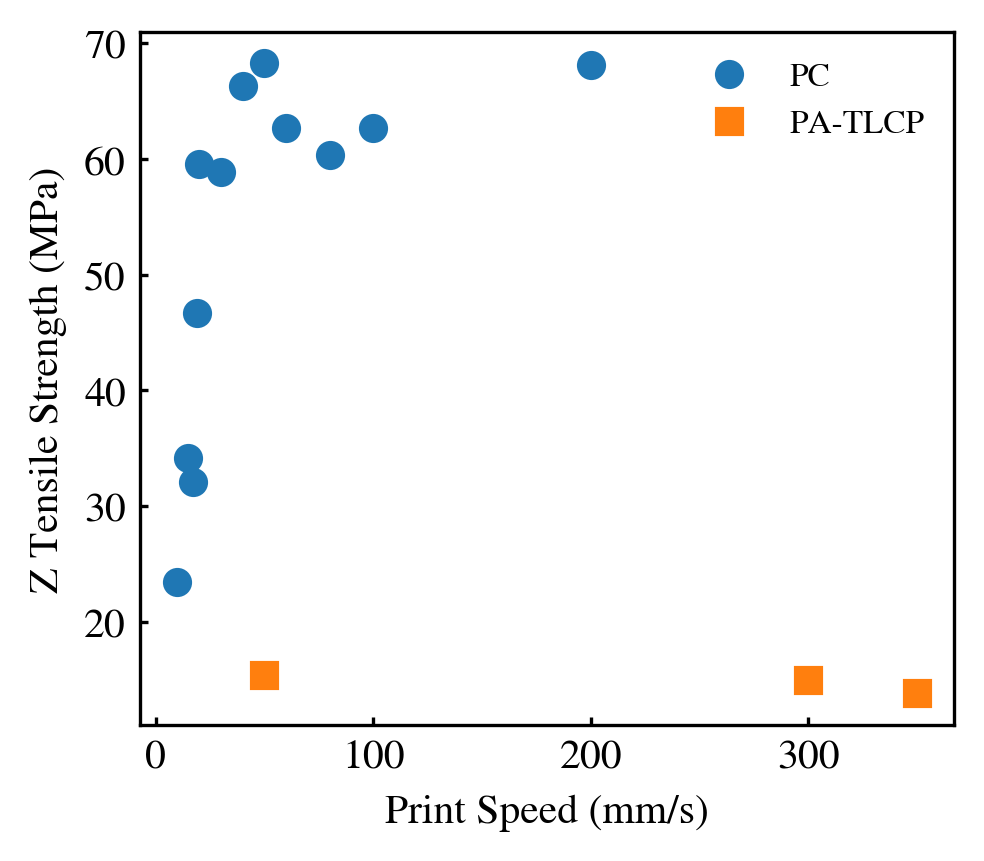

In [11]:
plt.figure(figsize=(3.5, 3), dpi=300)
plt.plot(pc["speed"], pc["z_tensile"], label="PC", marker="o", ls="")
plt.plot(pa["speed"], pa["z_tensile"], label="PA-TLCP", marker="s", ls="")
plt.xlabel("Print Speed (mm/s)")
plt.ylabel("Z Tensile Strength (MPa)")
plt.legend(fontsize=8, frameon=False)

## 2 Flow rate ratio

(0.0, 10.0)

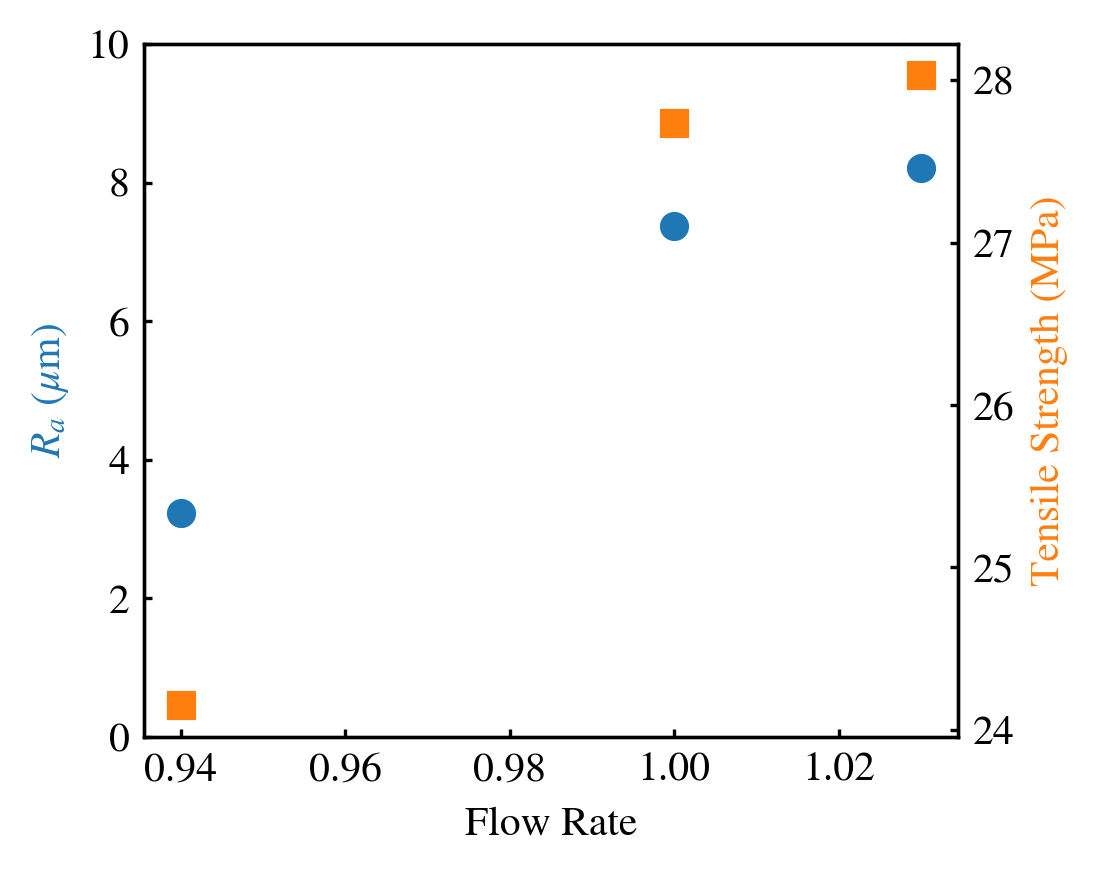

In [14]:
flow = [0.94, 1, 1.03]
ra = [3.23, 7.37, 8.21]
TS = [24.15, 27.74,28.03]

cmap = plt.get_cmap("tab10")
fig, ax = plt.subplots(figsize=(3.5, 3), dpi=300)
ax.plot(flow, ra, label="RA", marker="o", ls="")
ax2 = ax.twinx()
ax2.plot(flow, TS, label="TS", marker="s", ls="", color=cmap(1))
ax.set_xlabel("Flow Rate")
ax.set_ylabel("$R_a$ ($\\mu$m)", color=cmap(0))
ax2.set_ylabel("Tensile Strength (MPa)", color=cmap(1))
ax.set_ylim(0, 10)

## 3 Fan speed

Text(0, 0.5, 'Tensile Strength (MPa)')

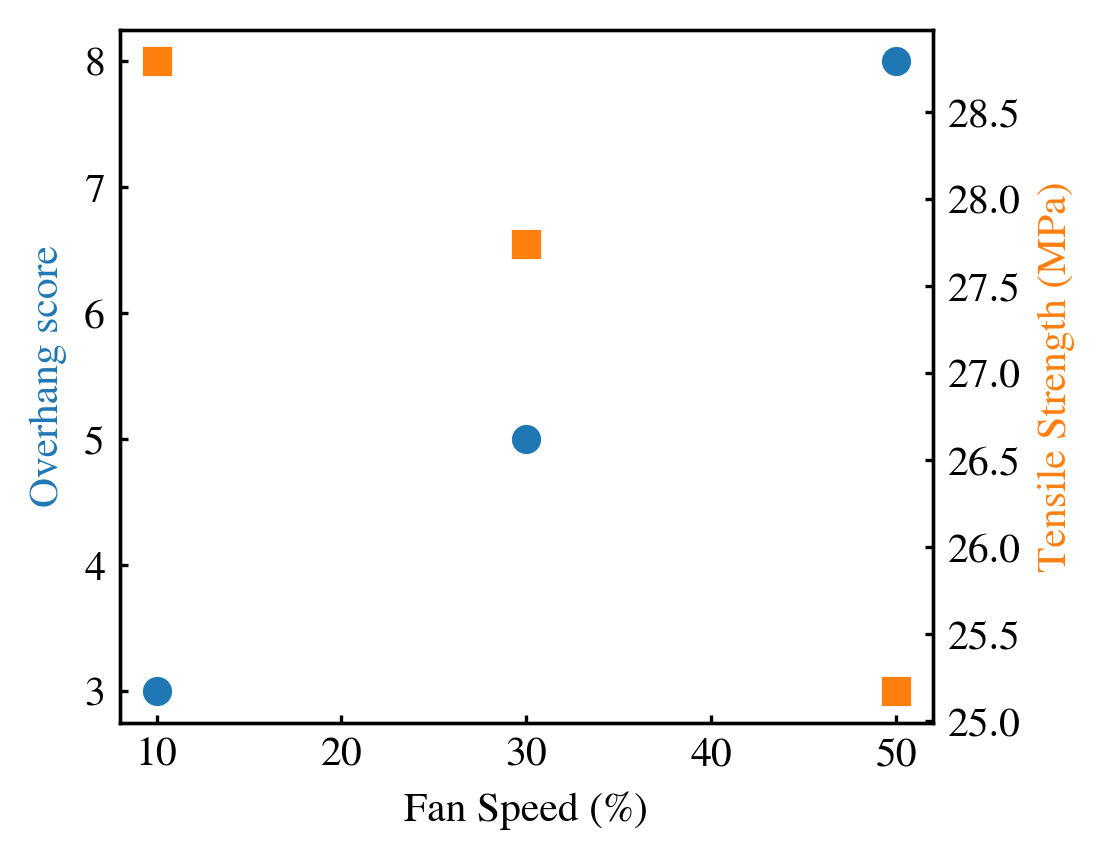

In [16]:
fan = [10, 30, 50]
oh = [3, 5, 8]
ts = [28.79, 27.74, 25.17]

fig, ax = plt.subplots(figsize=(3.5, 3), dpi=300)
ax.plot(fan, oh, label="OH", marker="o", ls="")
ax2 = ax.twinx()
ax2.plot(fan, ts, label="TS", marker="s", ls="", color=cmap(1))
ax.set_xlabel("Fan Speed (%)")
ax.set_ylabel("Overhang score", color=cmap(0))
ax2.set_ylabel("Tensile Strength (MPa)", color=cmap(1))

## 4 Layer time

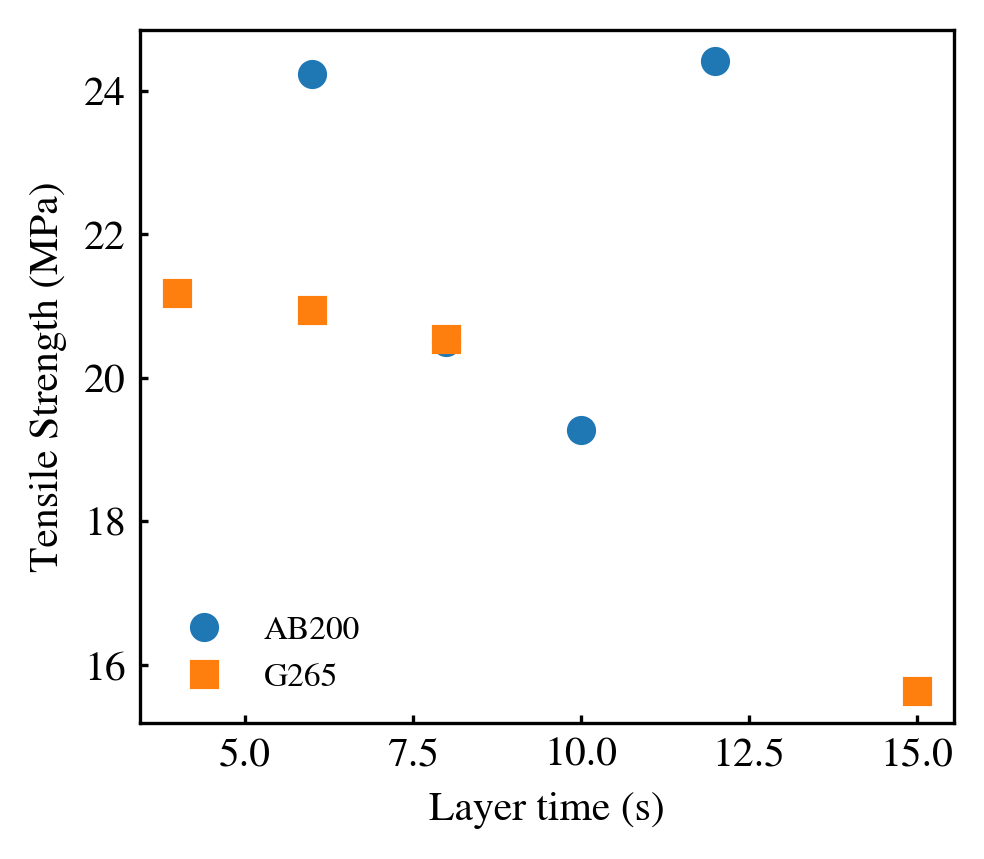

In [20]:
lt = [6, 8, 10, 12]
ts = [24.23, 20.5, 19.28, 24.41]
lt2 = [4, 6, 8, 15]
ts2 = [21.18, 20.95, 20.54, 15.63]


plt.figure(figsize=(3.5, 3), dpi=300)
plt.plot(lt, ts, label="AB200", marker="o", ls="")
plt.plot(lt2, ts2, label="G265", marker="s", ls="")
plt.xlabel("Layer time (s)")
plt.ylabel("Tensile Strength (MPa)")
plt.legend(fontsize=8, frameon=False, loc="lower left")

(0.0, 80.0)

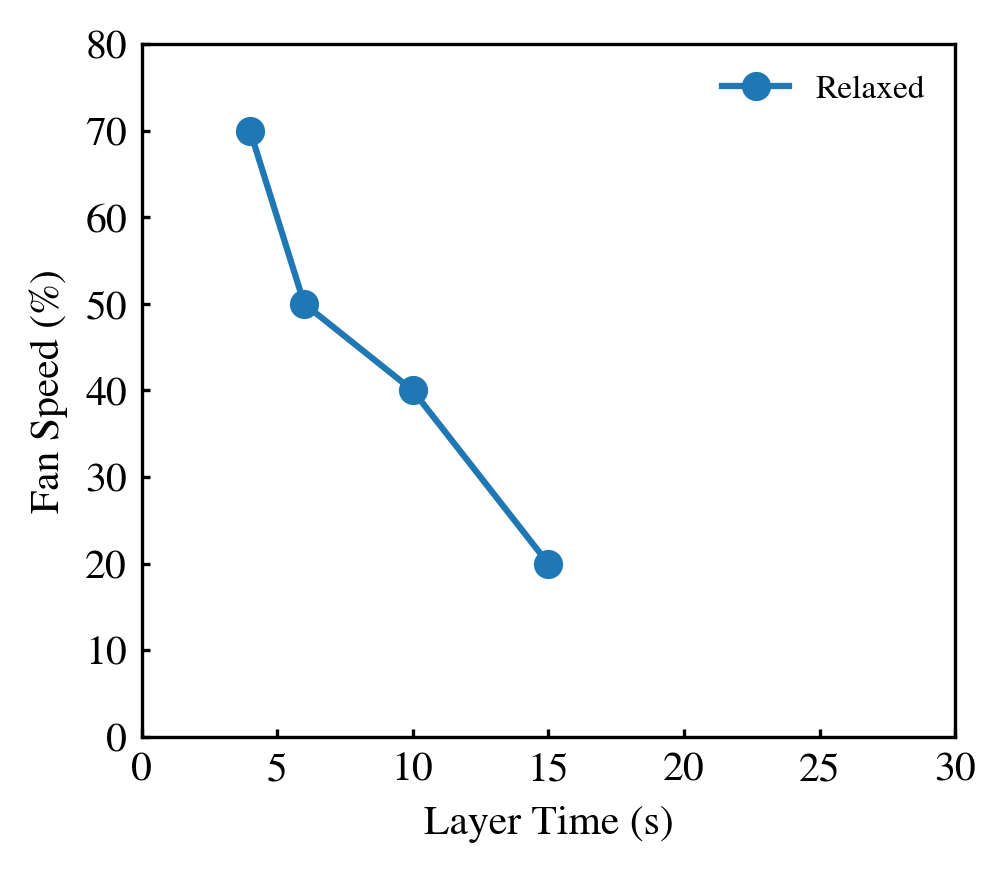

In [4]:
fan_strict = [80, 70, 60, 50, 20, 10]
lt_strict = [4, 6, 8, 10, 15, 30]
fan = [70, 50, 40, 20]
lt = [4, 6, 10, 15]
fan_preset = [30, 10]
lt_preset = [12, 30]

plt.figure(figsize=(3.5, 3), dpi=300)
# plt.plot(lt_strict, fan_strict,label="Strict", marker="o")
plt.plot(lt, fan, label="Relaxed", marker="o")
# plt.plot(lt_preset, fan_preset, label="Preset", marker="o")
plt.xlabel("Layer Time (s)")
plt.ylabel("Fan Speed (%)")
plt.legend(fontsize=8, frameon=False, loc="upper right")
plt.xlim(0, 30)
plt.ylim(0, 80)

## 5 Iso-appearance line overlay on z-tensile data

In [129]:
folder = Path("/Users/zhengyang/Documents/preset_proj")
df = pd.read_csv(folder / "ztensile.csv", usecols=[0,1,2,3,4,5,7])

In [130]:
df

,材料,层时间（s）,风扇开度（%）,拉伸强度（MPa）,拉伸强度标准差（MPa）,等分线判定标准,打印机型号
0,AB200,4,80,25.19,0.22,Strict,H2D
1,AB200,6,70,24.23,0.85,Strict,H2D
2,AB200,8,60,20.5,0.49,Strict,H2D
3,AB200,10,50,19.28,0.82,Strict,H2D
4,AB200,15,20,21.19,0.23,Strict,H2D
5,AB200,15,20,21.19,0.23,Relaxed,H2D
6,AB200,4,70,26.44,0.68,Relaxed,H2D
7,AB200,6,50,25.94,0.18,Relaxed,H2D
8,AB200,8,50,23.4,0.4,Relaxed,H2D
9,AB200,10,40,23.05,0.25,Relaxed,H2D


In [131]:
df_ab = df.loc[(df["材料"]=="C525") & (df["打印机型号"]=="H2C")]
ab_strict = df_ab.loc[df_ab["等分线判定标准"]=="Strict"].sort_values(by=["层时间（s）"])
ab_relaxed = df_ab.loc[df_ab["等分线判定标准"]=="Relaxed"].sort_values(by=["层时间（s）"])

In [132]:
data = df_ab.values[:, 1:4].astype(float)

In [138]:
data

array([[ 4.  , 80.  , 38.44],
       [ 6.  , 60.  , 30.79],
       [ 8.  , 40.  , 30.03],
       [15.  , 20.  , 30.29],
       [15.  , 20.  , 30.29],
       [ 4.  , 60.  , 36.84],
       [ 6.  , 40.  , 31.6 ]])

In [133]:
x, y, z = data[:, 0], data[:, 1], data[:, 2]

from scipy.interpolate import LinearNDInterpolator
import numpy as np
# fill_value=0：凸包（数据边界）之外的点直接返回 0，不做外推
interp = LinearNDInterpolator(list(zip(x, y)), z, fill_value=0.0)

In [139]:
xx, yy = np.meshgrid(np.linspace(x.min(), x.max(), 1000), np.linspace(y.min(), y.max(), 1000))
zz = interp(xx, yy)

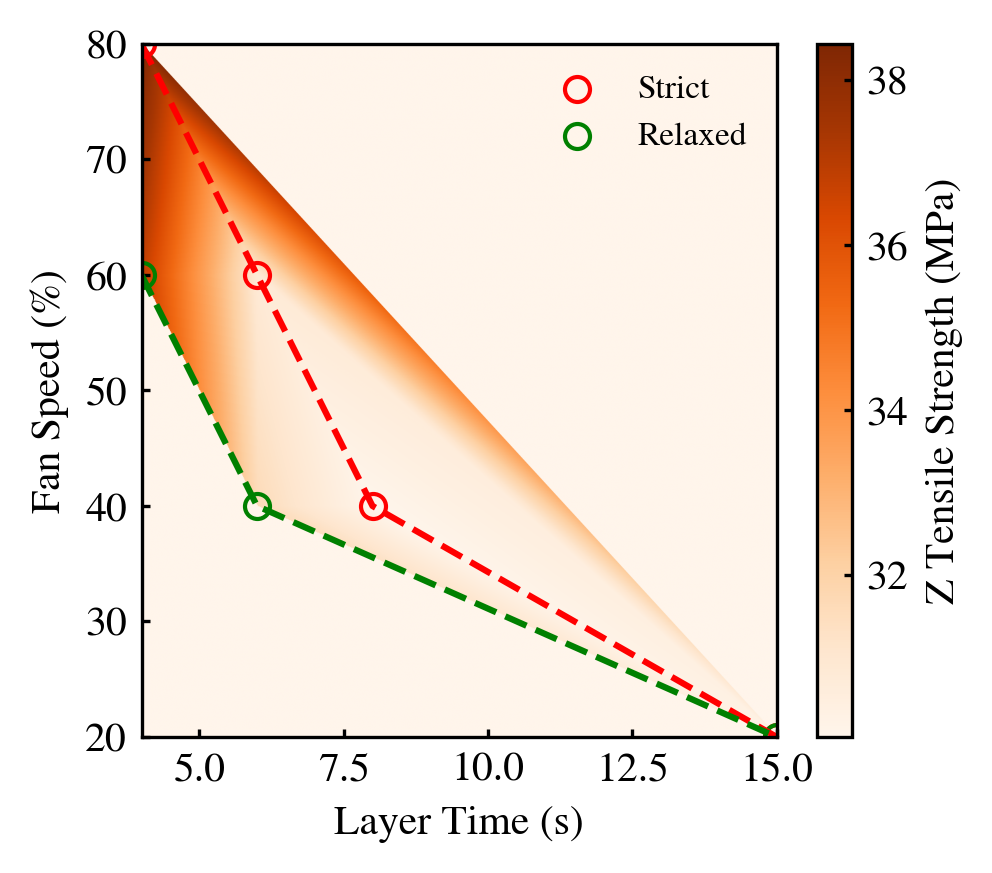

In [140]:
plt.figure(figsize=(3.5, 3), dpi=300)
plt.imshow(zz, vmin=z.min(), vmax=z.max(), 
           cmap="Oranges", origin="lower", 
           extent=[x.min(), x.max(), y.min(), y.max()],
           aspect=0.20)
plt.colorbar(label="Z Tensile Strength (MPa)")
plt.xlabel("Layer Time (s)")
plt.ylabel("Fan Speed (%)")
plt.scatter(ab_strict["层时间（s）"], ab_strict["风扇开度（%）"], label="Strict", marker="o", edgecolor="red", facecolor=(0,0,0,0))
plt.scatter(ab_relaxed["层时间（s）"], ab_relaxed["风扇开度（%）"], label="Relaxed", marker="o", edgecolor="green", facecolor=(0,0,0,0))
plt.plot(ab_strict["层时间（s）"], ab_strict["风扇开度（%）"], color="red", ls="--")
plt.plot(ab_relaxed["层时间（s）"], ab_relaxed["风扇开度（%）"], color="green", ls="--")
plt.legend(fontsize=8, frameon=False, loc="upper right")

## 6 XY vs. Z

To assess whether cooling is too much, we want to compare the XY tensile strength with Z. This is on the assumption that, if sufficiently heated, the interlayer bonding can reach the highest possible strength - the XY tensile strength. In this section, we analyze more than 400 mechanical tests in the past, to see if this is a viable method. 

In [4]:
df = pd.read_excel(r"~\Downloads\ztensile.xlsx")

In [6]:
df.columns

Index(['data_id', '标题', '拉伸测试数据编号', '测试任务代码', '测试线卷序号 | Test spool No.',
       '线材品牌 | Filament brand', '线材配方号 | Filament formulation ID',
       '线材产品类别 | Filament product type', '线材基材种类 | Filament material type',
       '测试线卷描述 | Test spool description', '样品信息 | Sample Info', '标准测试方法',
       '方法版本号', '打印机品牌 | Printer Brand', '打印机型号 | Printer Name',
       '打印温度（℃）| Print temperature', '打印速度（mm/s）| Printer Speed',
       '风扇设置 | Fan Setting', '样品后处理 | Specimen treatment',
       '打印方向 | Print Direction', '测试参数 | Test Info',
       '拉伸强度 | Tensile Strength (MPa)',
       '拉伸强度标准差 | Tensile Strength Deviation (MPa)',
       '拉伸模量 | Tensile Modulus (GPa)',
       '拉伸模量标准差 | Tensile Modulus Deviation (GPa)',
       '断裂伸长率 | Elogation at break (%)',
       '断裂伸长率标准差 | Elogation at break Deviation (%)', '测试结果 | Test result',
       '提交人', '提交时间', '更新时间'],
      dtype='str')

In [19]:
gs = df.loc[df["方法版本号"]=="V1.0"].groupby("线材配方号 | Filament formulation ID")

In [33]:
n = 0
xyz_list = []
for pi, g in gs:
    if len(g["打印方向 | Print Direction"].unique()) > 1:
        print(pi)
        print(g[["打印方向 | Print Direction", '方法版本号',  '拉伸强度 | Tensile Strength (MPa)']])
        tmp = {"picode": pi}
        for di, gd in g.groupby("打印方向 | Print Direction"):
            tmp = {**tmp, di: gd["拉伸强度 | Tensile Strength (MPa)"].mean()}
        xyz_list.append(tmp)

1002
    打印方向 | Print Direction 方法版本号  拉伸强度 | Tensile Strength (MPa)
161                     XY  V1.0                           43.9
298                      Z  V1.0                           33.9
3002
    打印方向 | Print Direction 方法版本号  拉伸强度 | Tensile Strength (MPa)
225                     XY  V1.0                           39.3
348                      Z  V1.0                           28.0
ABS+
    打印方向 | Print Direction 方法版本号  拉伸强度 | Tensile Strength (MPa)
317                     XY  V1.0                           31.6
356                      Z  V1.0                           21.4
ABS-GF
    打印方向 | Print Direction 方法版本号  拉伸强度 | Tensile Strength (MPa)
138                     XY  V1.0                           37.2
309                      Z  V1.0                           21.5
ABS01
    打印方向 | Print Direction 方法版本号  拉伸强度 | Tensile Strength (MPa)
241                     XY  V1.0                           33.4
294                      Z  V1.0                           29.7
ABSCF
    打印

In [35]:
df = pd.DataFrame(data=xyz_list)

In [50]:
ind = [("CF" in picode) or ("GF" in picode) for picode in df["picode"]]
fibre = df.loc[ind]
nonfibre = df.loc[[not x for x in ind]]

In [48]:
fibre.shape

(31, 3)

(0.0, 100.0)

c:\Users\liuzy\Documents\GitHub\Boralus\.venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 26408 (\N{CJK UNIFIED IDEOGRAPH-6728}) missing from font(s) STIXGeneral.
  func(*args, **kwargs)
c:\Users\liuzy\Documents\GitHub\Boralus\.venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 36136 (\N{CJK UNIFIED IDEOGRAPH-8D28}) missing from font(s) STIXGeneral.
  func(*args, **kwargs)
c:\Users\liuzy\Documents\GitHub\Boralus\.venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 32993 (\N{CJK UNIFIED IDEOGRAPH-80E1}) missing from font(s) STIXGeneral.
  func(*args, **kwargs)
c:\Users\liuzy\Documents\GitHub\Boralus\.venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 26691 (\N{CJK UNIFIED IDEOGRAPH-6843}) missing from font(s) STIXGeneral.
  func(*args, **kwargs)
c:\Users\liuzy\Documents\GitHub\Boralus\.venv\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) ST

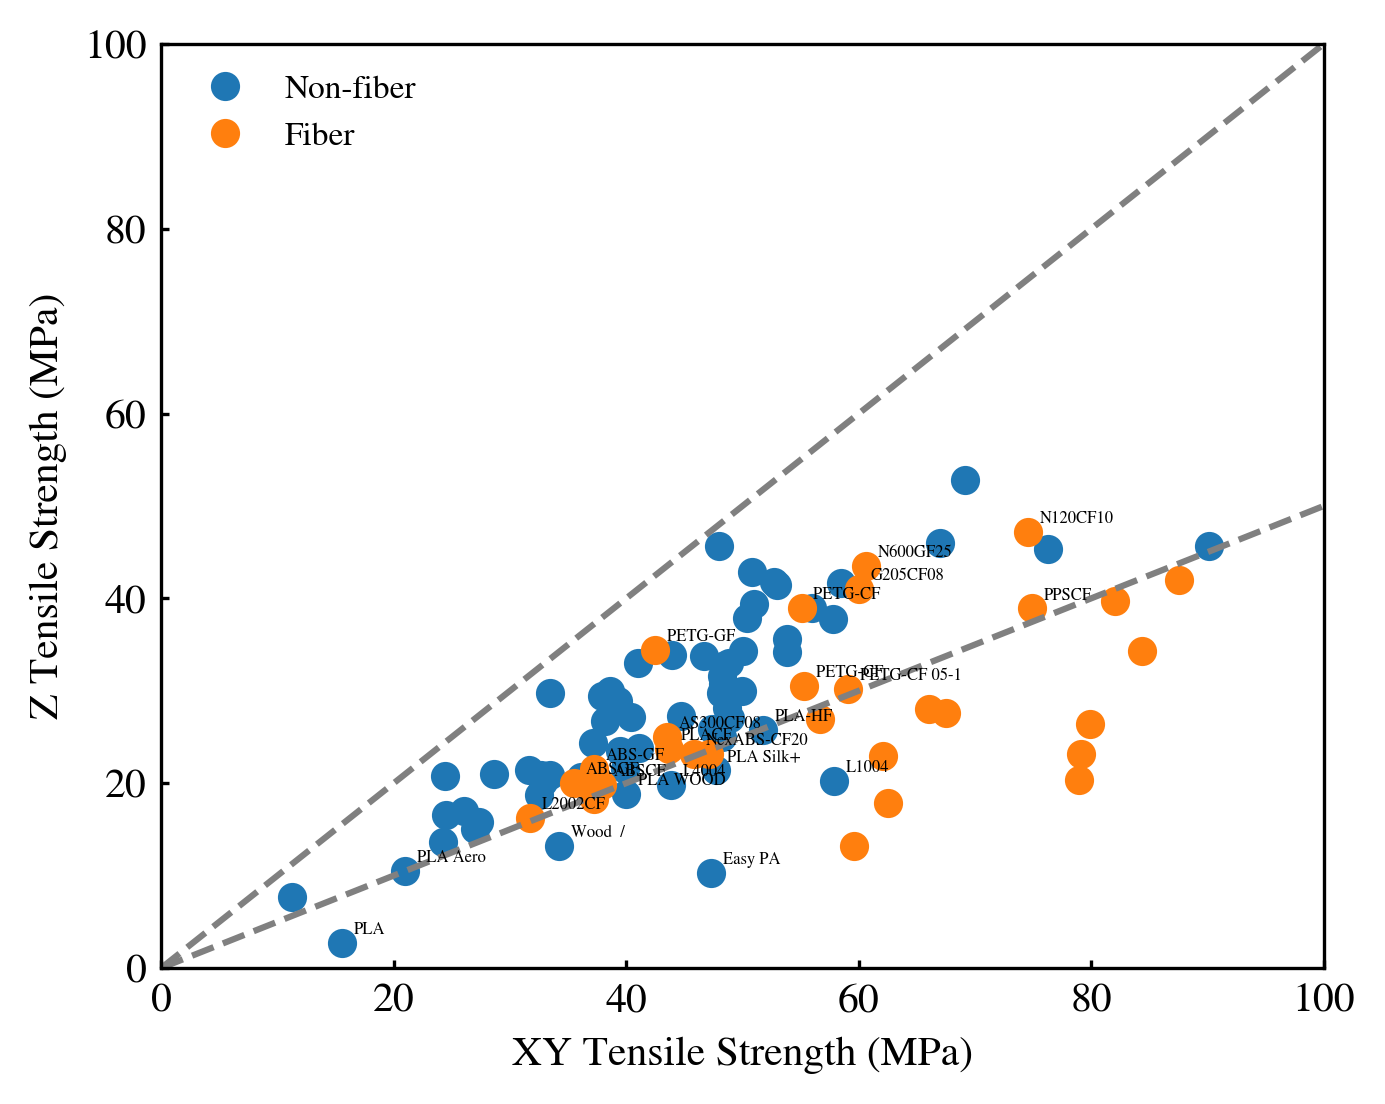

In [65]:
plt.figure(figsize=(5, 4), dpi=300)
plt.plot(nonfibre["XY"], nonfibre["Z"], marker="o", ls="", label="Non-fiber")
plt.plot(fibre["XY"], fibre["Z"], marker="o", ls="", label="Fiber")
plt.plot([0, 100], [0, 100], ls="--", color="gray")
# plt.plot([0, 100], [0, 80], ls="--", color="gray")
plt.plot([0, 100], [0, 50], ls="--", color="gray")
for i, row in nonfibre.iterrows():
    if row["Z"] < row["XY"] / 2:
        plt.text(row["XY"]+1, row["Z"]+1, row["picode"], fontsize=4)
for i, row in fibre.iterrows():
    if row["Z"] > row["XY"] / 2:
        plt.text(row["XY"]+1, row["Z"]+1, row["picode"], fontsize=4)
plt.legend(frameon=False, fontsize=8)
plt.xlabel("XY Tensile Strength (MPa)")
plt.ylabel("Z Tensile Strength (MPa)")
plt.xlim(0, 100)
plt.ylim(0, 100)